In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python EDA environment is ready!")

Matplotlib is building the font cache; this may take a moment.


Python EDA environment is ready!


In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

candidates = pd.read_csv(DATA_DIR / "candidates.csv")
jobs = pd.read_csv(DATA_DIR / "jobs.csv")
applications = pd.read_csv(DATA_DIR / "applications.csv")
interviews = pd.read_csv(DATA_DIR / "interviews.csv")
offers = pd.read_csv(DATA_DIR / "offers.csv")
hires = pd.read_csv(DATA_DIR / "hires.csv")
recruiters = pd.read_csv(DATA_DIR / "recruiters.csv")
sources = pd.read_csv(DATA_DIR / "sources.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
# Check the size of each dataset

print("Candidates:", candidates.shape)
print("Jobs:", jobs.shape)
print("Applications:", applications.shape)
print("Interviews:", interviews.shape)
print("Offers:", offers.shape)
print("Hires:", hires.shape)
print("Recruiters:", recruiters.shape)
print("Sources:", sources.shape)

Candidates: (2000, 8)
Jobs: (30, 7)
Applications: (10000, 7)
Interviews: (3049, 7)
Offers: (1533, 5)
Hires: (486, 5)
Recruiters: (20, 3)
Sources: (15, 2)


In [4]:
applications.head()

,application_id,candidate_id,job_id,source_id,recruiter_id,application_date,application_status
0,1,29,2,1,19,2025-04-16,Rejected
1,2,102,19,11,1,2025-07-22,Screening
2,3,123,14,11,18,2025-10-30,Rejected
3,4,54,8,5,17,2025-06-09,Interview
4,5,1307,19,1,1,2025-08-29,Applied


In [5]:
# Check missing values

applications.isnull().sum()

application_id        0
candidate_id          0
job_id                0
source_id             0
recruiter_id          0
application_date      0
application_status    0
dtype: int64

In [6]:
# Check duplicate rows

applications.duplicated().sum()

np.int64(0)

In [7]:
# Check duplicate rows

applications.duplicated().sum()

np.int64(0)

In [8]:
# Check data types

applications.dtypes

application_id        int64
candidate_id          int64
job_id                int64
source_id             int64
recruiter_id          int64
application_date        str
application_status      str
dtype: object

In [9]:
# Applications by job role

job_applications = (
    applications
    .merge(jobs[['job_id', 'job_title']], on='job_id')
    .groupby('job_title')
    .size()
    .sort_values(ascending=False)
)

job_applications

job_title
Data Scientist                   2767
Product Analyst                  1027
ML Engineer                       997
Product Manager                   964
Business Analyst                  953
Frontend Developer                952
Software Engineer                 720
Business Intelligence Analyst     692
Backend Developer                 628
Data Analyst                      300
dtype: int64

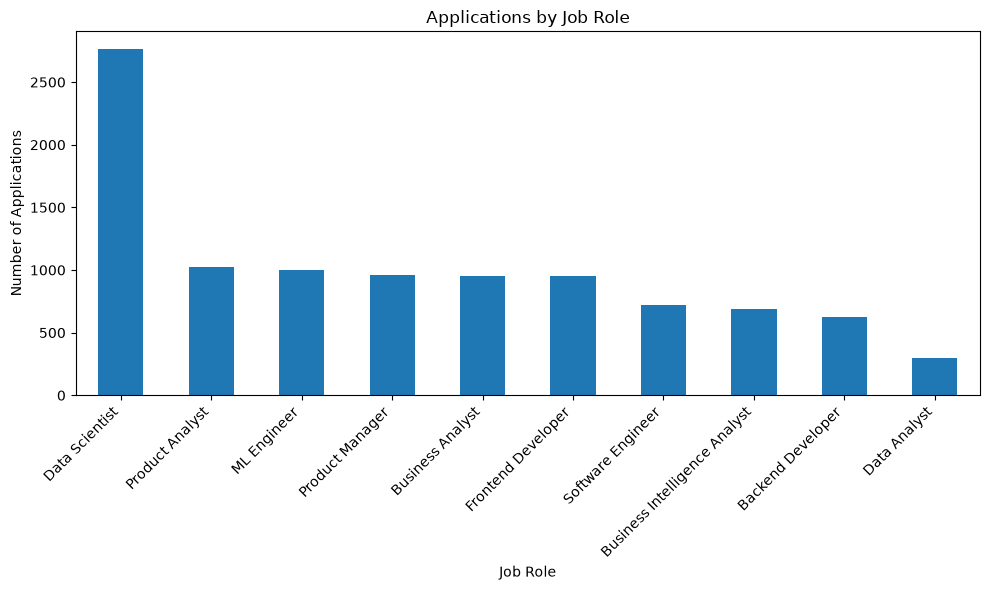

In [10]:
plt.figure(figsize=(10, 6))

job_applications.plot(kind='bar')

plt.title('Applications by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
source_applications = (
    applications
    .merge(sources[['source_id', 'source_name']], on='source_id')
    .groupby('source_name')
    .size()
    .sort_values(ascending=False)
)

source_applications

source_name
Naukri               1757
LinkedIn             1485
Referral             1023
Company Website      1007
Indeed                790
Employee Referral     612
Campus Hiring         604
Internshala           553
Glassdoor             475
Consultancy           394
Hirect                303
CutShort              297
Job Fair              291
Other                 207
AngelList             202
dtype: int64

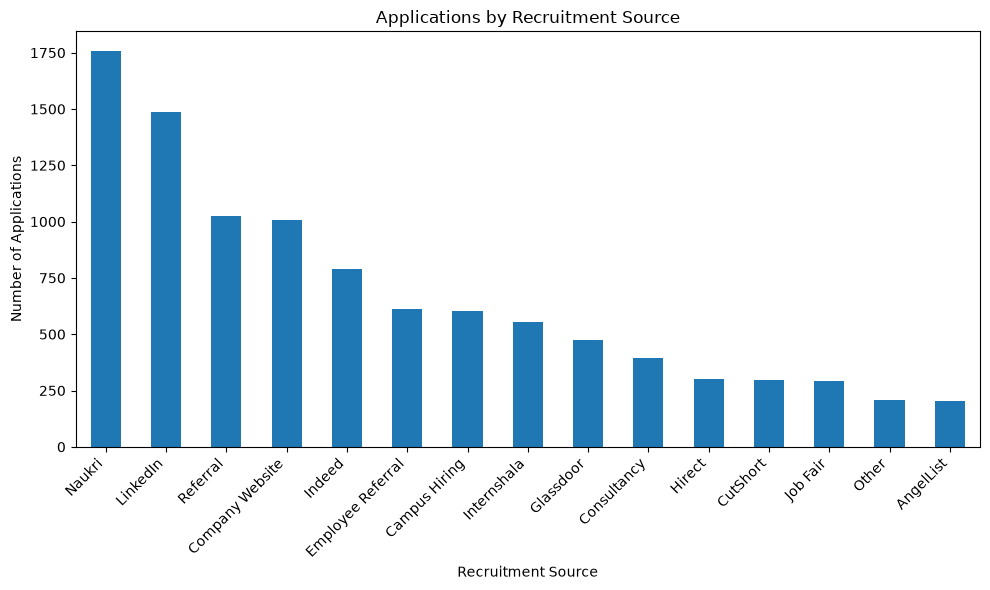

In [12]:
plt.figure(figsize=(10, 6))

source_applications.plot(kind='bar')

plt.title('Applications by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
role_source = (
    applications
    .merge(jobs[['job_id', 'job_title']], on='job_id')
    .merge(sources[['source_id', 'source_name']], on='source_id')
    .groupby(['job_title', 'source_name'])
    .size()
    .reset_index(name='applications')
)

role_source.head(20)

,job_title,source_name,applications
0,Backend Developer,AngelList,6
1,Backend Developer,Campus Hiring,40
2,Backend Developer,Company Website,70
3,Backend Developer,Consultancy,19
4,Backend Developer,CutShort,21
5,Backend Developer,Employee Referral,42
6,Backend Developer,Glassdoor,37
7,Backend Developer,Hirect,17
8,Backend Developer,Indeed,43
9,Backend Developer,Internshala,34


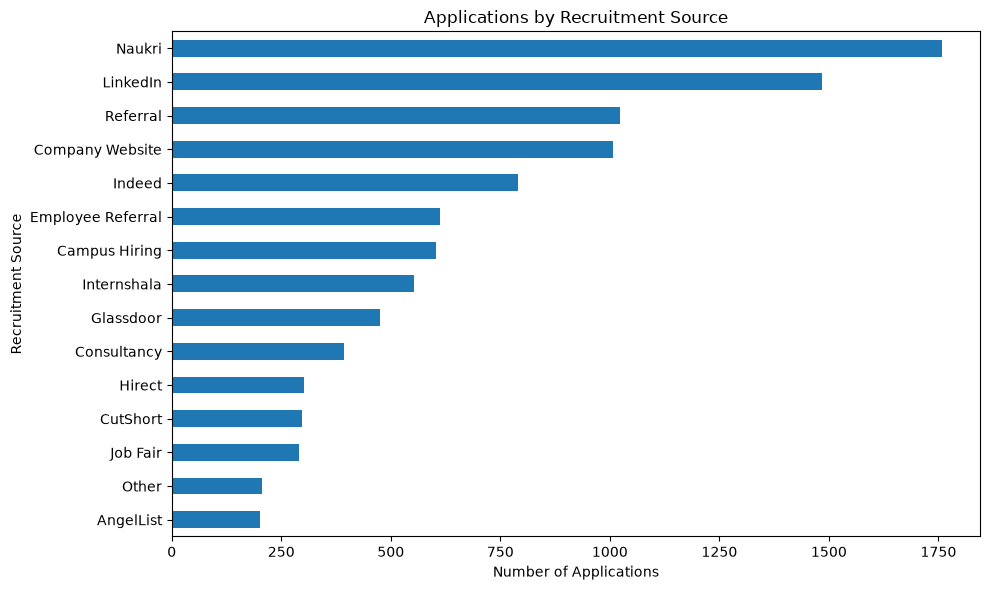

In [14]:
plt.figure(figsize=(10, 6))

source_applications.sort_values().plot(kind='barh')

plt.title('Applications by Recruitment Source')
plt.xlabel('Number of Applications')
plt.ylabel('Recruitment Source')

plt.tight_layout()
plt.show()

In [15]:
funnel = {
    'Applications': len(applications),
    'Interviews': interviews['application_id'].nunique(),
    'Offers': offers['application_id'].nunique(),
    'Hires': hires['application_id'].nunique()
}

funnel_df = pd.DataFrame(
    list(funnel.items()),
    columns=['Stage', 'Candidates']
)

funnel_df

,Stage,Candidates
0,Applications,10000
1,Interviews,3049
2,Offers,1533
3,Hires,486


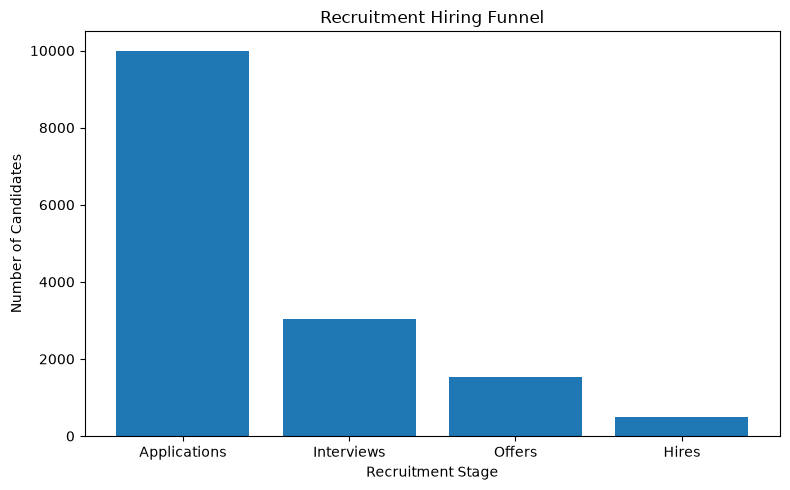

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(funnel_df['Stage'], funnel_df['Candidates'])

plt.title('Recruitment Hiring Funnel')
plt.xlabel('Recruitment Stage')
plt.ylabel('Number of Candidates')

plt.tight_layout()
plt.show()

In [17]:
funnel_df['Conversion_Rate_%'] = (
    funnel_df['Candidates'] / funnel_df['Candidates'].iloc[0] * 100
).round(2)

funnel_df

,Stage,Candidates,Conversion_Rate_%
0,Applications,10000,100.00
1,Interviews,3049,30.49
2,Offers,1533,15.33
3,Hires,486,4.86


In [18]:
applications['application_date'] = pd.to_datetime(applications['application_date'])
hires['hire_date'] = pd.to_datetime(hires['hire_date'])

time_to_hire = (
    applications[['application_id', 'application_date']]
    .merge(
        hires[['application_id', 'hire_date']],
        on='application_id'
    )
)

time_to_hire['days_to_hire'] = (
    time_to_hire['hire_date'] - time_to_hire['application_date']
).dt.days

time_to_hire['days_to_hire'].describe()

count    486.000000
mean      40.216049
std       11.012113
min       20.000000
25%       31.000000
50%       41.000000
75%       49.750000
max       59.000000
Name: days_to_hire, dtype: float64

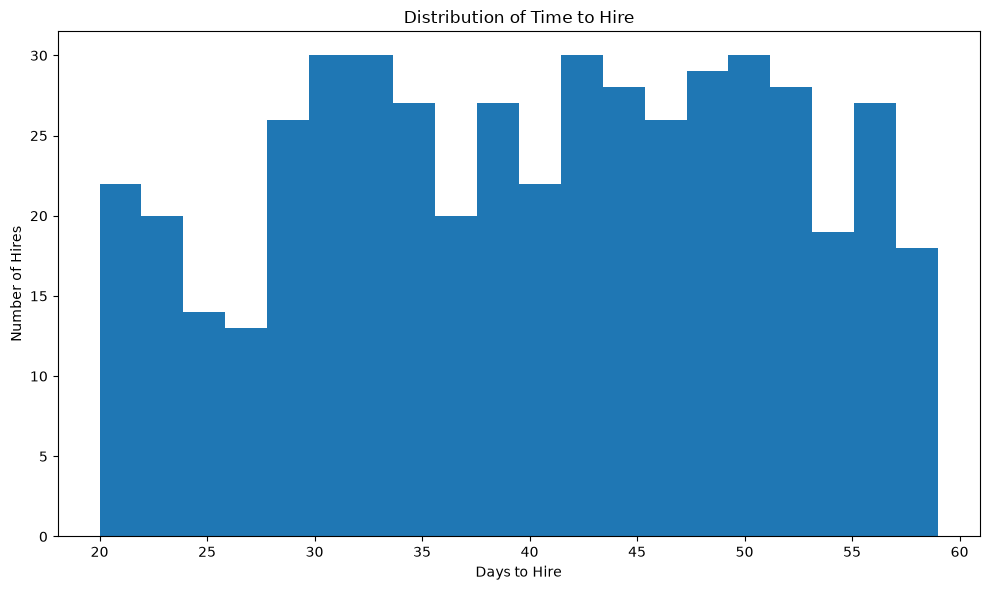

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(time_to_hire['days_to_hire'], bins=20)

plt.title('Distribution of Time to Hire')
plt.xlabel('Days to Hire')
plt.ylabel('Number of Hires')

plt.tight_layout()
plt.show()

In [20]:
role_time_to_hire = (
    applications[['application_id', 'job_id', 'application_date']]
    .merge(
        hires[['application_id', 'hire_date']],
        on='application_id'
    )
    .merge(
        jobs[['job_id', 'job_title']],
        on='job_id'
    )
)

role_time_to_hire['days_to_hire'] = (
    role_time_to_hire['hire_date']
    - role_time_to_hire['application_date']
).dt.days

role_time_summary = (
    role_time_to_hire
    .groupby('job_title')['days_to_hire']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

role_time_summary

job_title
Data Analyst                     44.24
Software Engineer                43.04
Business Analyst                 42.26
Data Scientist                   41.07
Frontend Developer               40.08
Backend Developer                40.00
Product Manager                  38.78
Business Intelligence Analyst    38.52
Product Analyst                  38.02
ML Engineer                      37.60
Name: days_to_hire, dtype: float64

In [21]:
role_salary = (
    offers
    .merge(
        applications[['application_id', 'job_id']],
        on='application_id'
    )
    .merge(
        jobs[['job_id', 'job_title']],
        on='job_id'
    )
    .groupby('job_title')['offered_salary']
    .agg(['count', 'mean', 'min', 'max'])
    .round(2)
    .sort_values('mean', ascending=False)
)

role_salary

,count,mean,min,max
job_title,,,,
Backend Developer,88,1151556.52,445718.37,1777241.70
Business Analyst,152,1135355.73,411494.93,1794323.42
Product Analyst,159,1135140.69,403711.69,1788552.89
ML Engineer,141,1119654.67,404732.66,1793139.56
Data Analyst,49,1109125.82,428422.65,1794509.20
Product Manager,166,1103928.32,403019.69,1797684.70
Business Intelligence Analyst,115,1095877.22,402278.60,1762511.90
Data Scientist,413,1093359.74,404099.52,1797374.33
Frontend Developer,133,1093039.91,416956.09,1783907.24


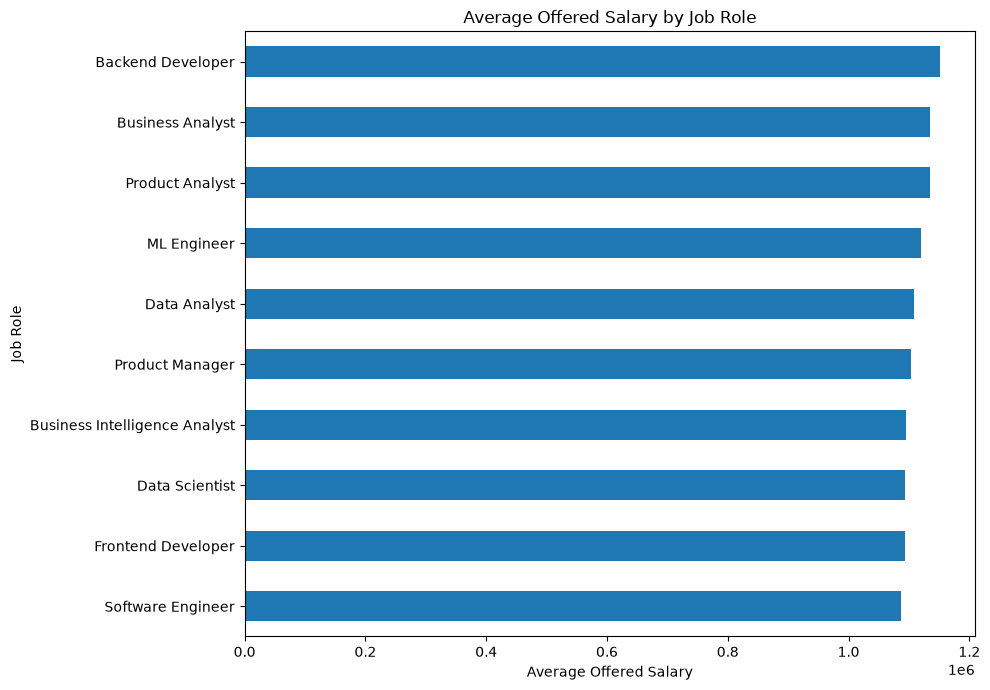

In [22]:
plt.figure(figsize=(10, 7))

role_salary['mean'].sort_values().plot(kind='barh')

plt.title('Average Offered Salary by Job Role')
plt.xlabel('Average Offered Salary')
plt.ylabel('Job Role')

plt.tight_layout()
plt.show()

In [23]:
recruiter_performance = (
    applications
    .merge(
        recruiters[['recruiter_id', 'recruiter_name']],
        on='recruiter_id'
    )
    .merge(
        hires[['application_id']],
        on='application_id',
        how='left',
        indicator=True
    )
)

recruiter_summary = (
    recruiter_performance
    .assign(
        hired=lambda x: x['_merge'].eq('both')
    )
    .groupby('recruiter_name')
    .agg(
        applications=('application_id', 'nunique'),
        hires=('hired', 'sum')
    )
)

recruiter_summary['conversion_rate_%'] = (
    recruiter_summary['hires']
    / recruiter_summary['applications']
    * 100
).round(2)

recruiter_summary = recruiter_summary.sort_values(
    'conversion_rate_%',
    ascending=False
)

recruiter_summary

,applications,hires,conversion_rate_%
recruiter_name,,,
Isha Mehta,481,29,6.03
Vivek Kumar,516,31,6.01
Simran Reddy,522,31,5.94
Kavya Mishra,451,26,5.76
Karan Shah,529,29,5.48
Neha Kapoor,494,26,5.26
Priya Singh,493,25,5.07
Sneha Patel,473,24,5.07
Meera Shah,498,25,5.02


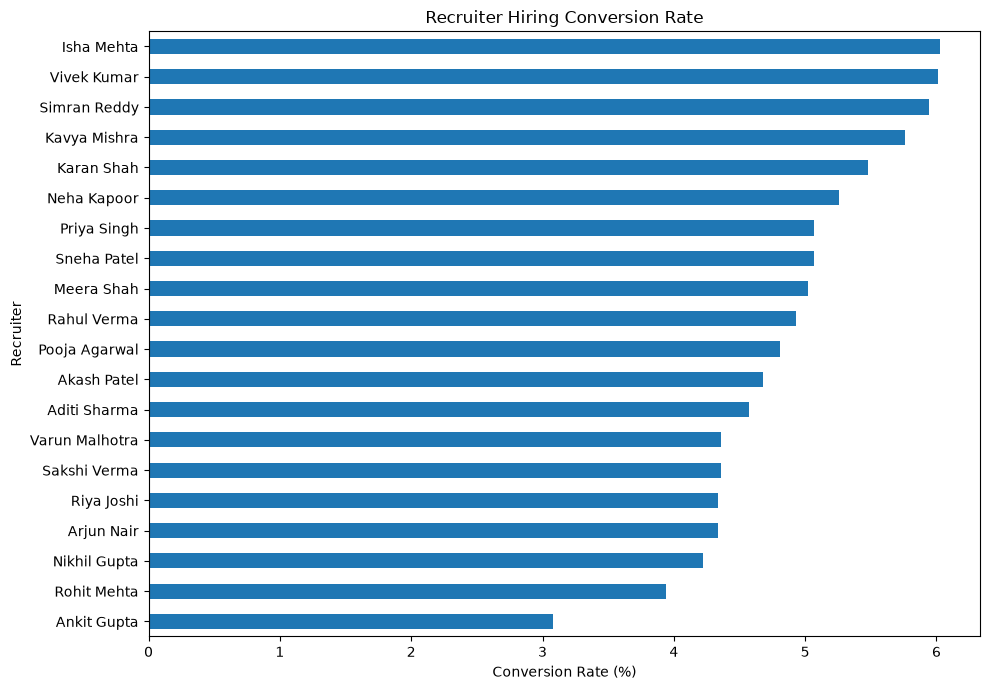

In [24]:
plt.figure(figsize=(10, 7))

recruiter_summary['conversion_rate_%'].sort_values().plot(kind='barh')

plt.title('Recruiter Hiring Conversion Rate')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Recruiter')

plt.tight_layout()
plt.show()

In [25]:
applications['application_date'] = pd.to_datetime(applications['application_date'])

monthly_applications = (
    applications
    .set_index('application_date')
    .resample('ME')
    .size()
)

monthly_applications

application_date
2025-01-31    866
2025-02-28    763
2025-03-31    861
2025-04-30    837
2025-05-31    832
2025-06-30    820
2025-07-31    825
2025-08-31    869
2025-09-30    842
2025-10-31    840
2025-11-30    832
2025-12-31    813
Freq: ME, dtype: int64

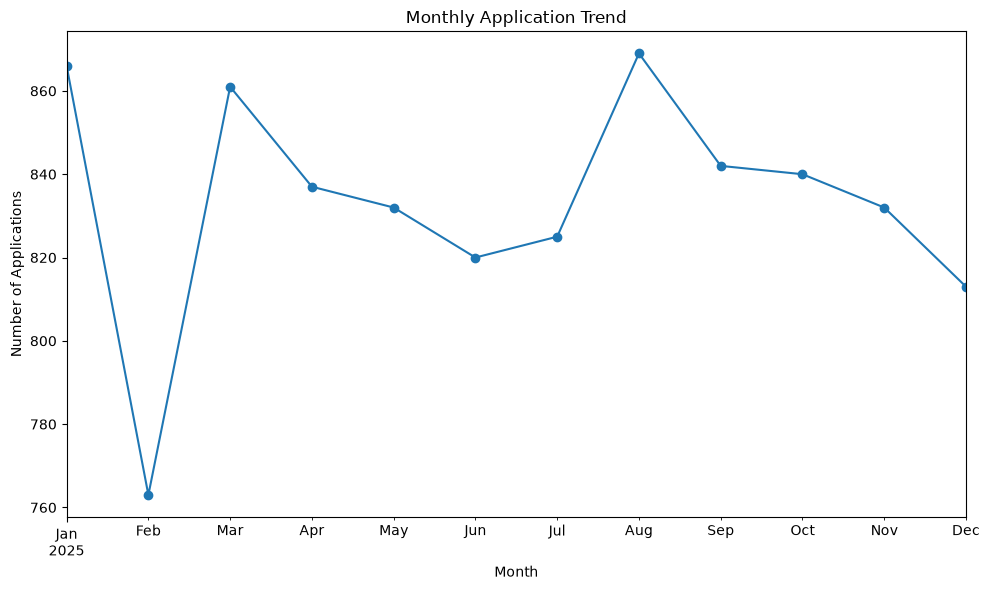

In [26]:
plt.figure(figsize=(10, 6))

monthly_applications.plot(kind='line', marker='o')

plt.title('Monthly Application Trend')
plt.xlabel('Month')
plt.ylabel('Number of Applications')

plt.tight_layout()
plt.show()

In [27]:
hires['hire_date'] = pd.to_datetime(hires['hire_date'])

monthly_hires = (
    hires
    .set_index('hire_date')
    .resample('ME')
    .size()
)

monthly_hires

hire_date
2025-01-31     1
2025-02-28    17
2025-03-31    47
2025-04-30    35
2025-05-31    42
2025-06-30    33
2025-07-31    49
2025-08-31    35
2025-09-30    51
2025-10-31    41
2025-11-30    45
2025-12-31    46
2026-01-31    36
2026-02-28     8
Freq: ME, dtype: int64

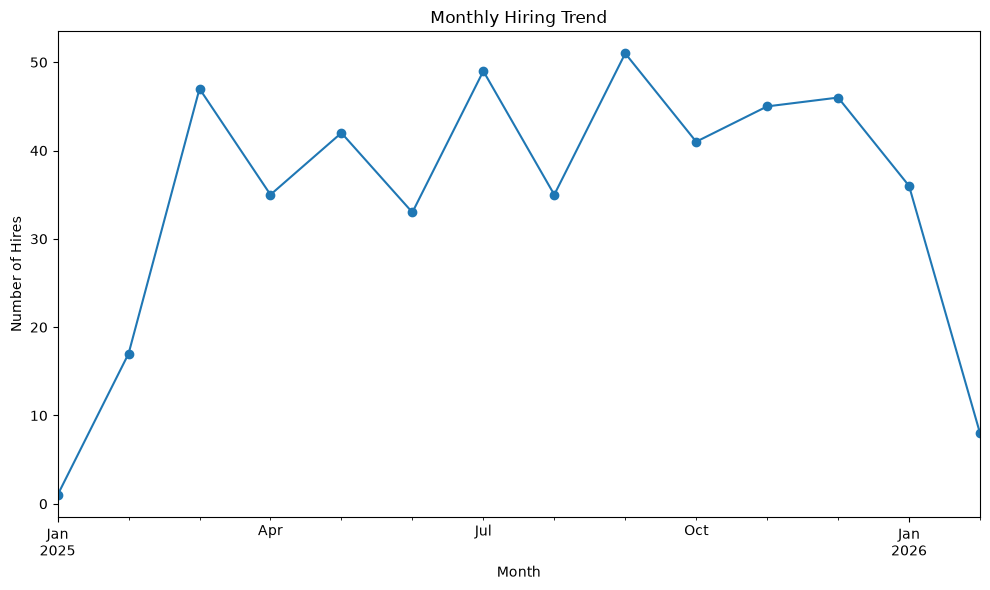

In [28]:
plt.figure(figsize=(10, 6))

monthly_hires.plot(kind='line', marker='o')

plt.title('Monthly Hiring Trend')
plt.xlabel('Month')
plt.ylabel('Number of Hires')

plt.tight_layout()
plt.show()

In [29]:
source_performance = (
    applications
    .merge(
        sources[['source_id', 'source_name']],
        on='source_id'
    )
    .merge(
        hires[['application_id']],
        on='application_id',
        how='left',
        indicator=True
    )
)

source_summary = (
    source_performance
    .assign(
        hired=lambda x: x['_merge'].eq('both')
    )
    .groupby('source_name')
    .agg(
        applications=('application_id', 'nunique'),
        hires=('hired', 'sum')
    )
)

source_summary['conversion_rate_%'] = (
    source_summary['hires']
    / source_summary['applications']
    * 100
).round(2)

source_summary = source_summary.sort_values(
    'conversion_rate_%',
    ascending=False
)

source_summary

,applications,hires,conversion_rate_%
source_name,,,
Consultancy,394,26,6.60
Employee Referral,612,35,5.72
Glassdoor,475,27,5.68
Hirect,303,17,5.61
Company Website,1007,55,5.46
Referral,1023,52,5.08
Naukri,1757,87,4.95
Other,207,10,4.83
Indeed,790,38,4.81


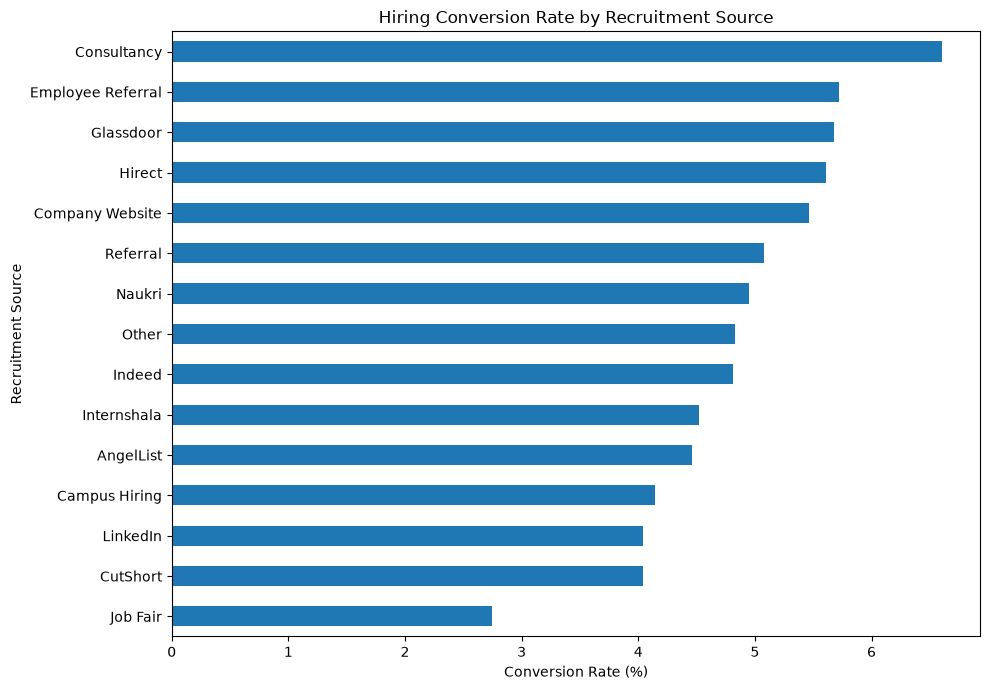

In [30]:
plt.figure(figsize=(10, 7))

source_summary['conversion_rate_%'].sort_values().plot(kind='barh')

plt.title('Hiring Conversion Rate by Recruitment Source')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Recruitment Source')

plt.tight_layout()
plt.show()

In [31]:
candidate_hiring = (
    applications
    .merge(
        candidates[['candidate_id', 'experience_years']],
        on='candidate_id'
    )
    .merge(
        hires[['application_id']],
        on='application_id',
        how='left',
        indicator=True
    )
)

experience_summary = (
    candidate_hiring
    .assign(
        hired=lambda x: x['_merge'].eq('both')
    )
    .groupby('experience_years')
    .agg(
        applications=('application_id', 'nunique'),
        hires=('hired', 'sum')
    )
)

experience_summary['conversion_rate_%'] = (
    experience_summary['hires']
    / experience_summary['applications']
    * 100
).round(2)

experience_summary

,applications,hires,conversion_rate_%
experience_years,,,
0.0,48,2,4.17
0.1,114,4,3.51
0.2,90,4,4.44
0.3,72,6,8.33
0.4,83,4,4.82
...,...,...,...
11.6,94,5,5.32
11.7,61,2,3.28
11.8,78,4,5.13


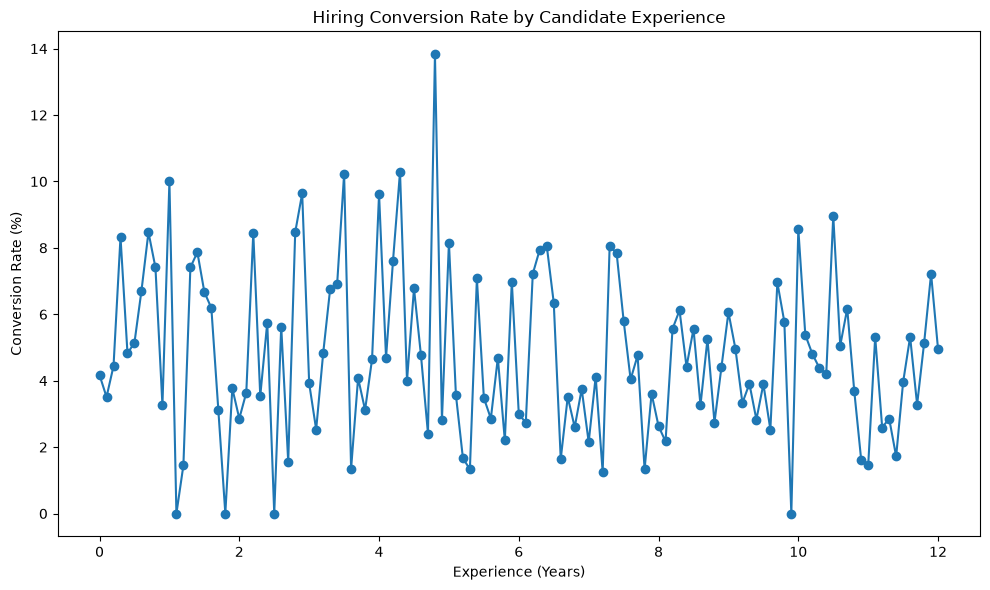

In [32]:
plt.figure(figsize=(10, 6))

experience_summary['conversion_rate_%'].plot(
    kind='line',
    marker='o'
)

plt.title('Hiring Conversion Rate by Candidate Experience')
plt.xlabel('Experience (Years)')
plt.ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

In [33]:
education_hiring = (
    applications
    .merge(
        candidates[['candidate_id', 'highest_education']],
        on='candidate_id'
    )
    .merge(
        hires[['application_id']],
        on='application_id',
        how='left',
        indicator=True
    )
)

education_summary = (
    education_hiring
    .assign(
        hired=lambda x: x['_merge'].eq('both')
    )
    .groupby('highest_education')
    .agg(
        applications=('application_id', 'nunique'),
        hires=('hired', 'sum')
    )
)

education_summary['conversion_rate_%'] = (
    education_summary['hires']
    / education_summary['applications']
    * 100
).round(2)

education_summary.sort_values(
    'conversion_rate_%',
    ascending=False
)

,applications,hires,conversion_rate_%
highest_education,,,
B.E.,1587,83,5.23
M.Tech,1418,74,5.22
MBA,1344,70,5.21
MCA,1389,70,5.04
M.Com,1372,67,4.88
B.Sc,1389,62,4.46
B.Tech,1501,60,4.00


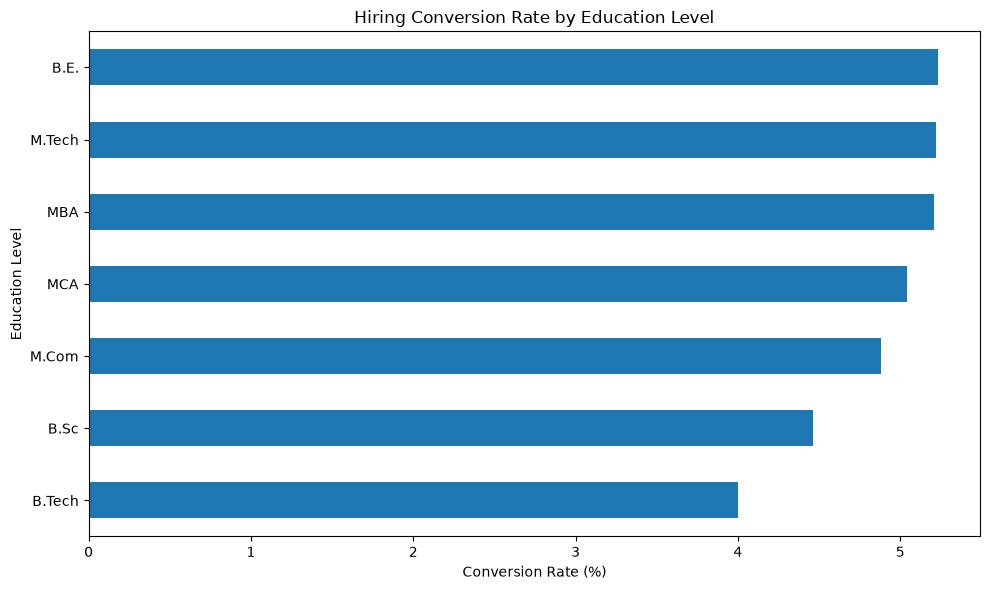

In [34]:
plt.figure(figsize=(10, 6))

education_summary['conversion_rate_%'].sort_values().plot(kind='barh')

plt.title('Hiring Conversion Rate by Education Level')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Education Level')

plt.tight_layout()
plt.show()

In [35]:
candidate_age = (
    applications
    .merge(
        candidates[['candidate_id', 'age']],
        on='candidate_id'
    )
    .merge(
        hires[['application_id']],
        on='application_id',
        how='left',
        indicator=True
    )
)

candidate_age['age_group'] = pd.cut(
    candidate_age['age'],
    bins=[0, 25, 30, 35, 40, 100],
    labels=['18-25', '26-30', '31-35', '36-40', '40+']
)

age_summary = (
    candidate_age
    .assign(
        hired=lambda x: x['_merge'].eq('both')
    )
    .groupby('age_group', observed=True)
    .agg(
        applications=('application_id', 'nunique'),
        hires=('hired', 'sum')
    )
)

age_summary['conversion_rate_%'] = (
    age_summary['hires']
    / age_summary['applications']
    * 100
).round(2)

age_summary

,applications,hires,conversion_rate_%
age_group,,,
18-25,2420,113,4.67
26-30,2659,131,4.93
31-35,2813,143,5.08
36-40,2108,99,4.70


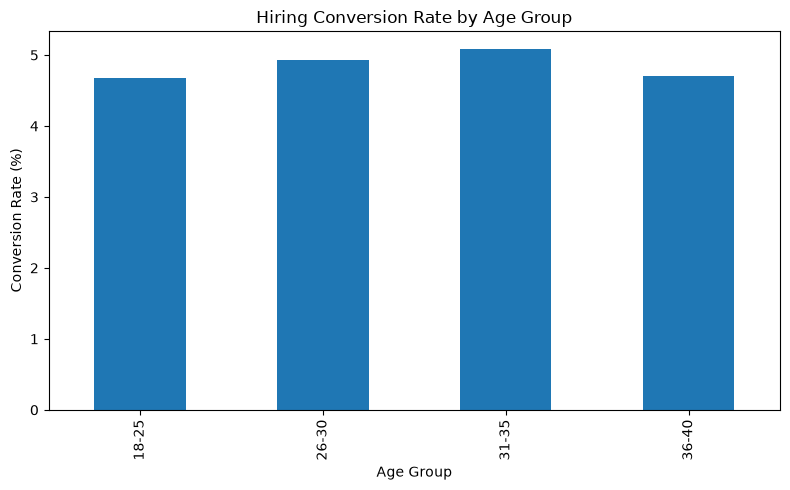

In [36]:
plt.figure(figsize=(8, 5))

age_summary['conversion_rate_%'].plot(kind='bar')

plt.title('Hiring Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

In [37]:
numeric_data = candidates[
    ['age', 'experience_years']
].copy()

correlation_matrix = numeric_data.corr()

correlation_matrix

,age,experience_years
age,1.000000,-0.014349
experience_years,-0.014349,1.000000


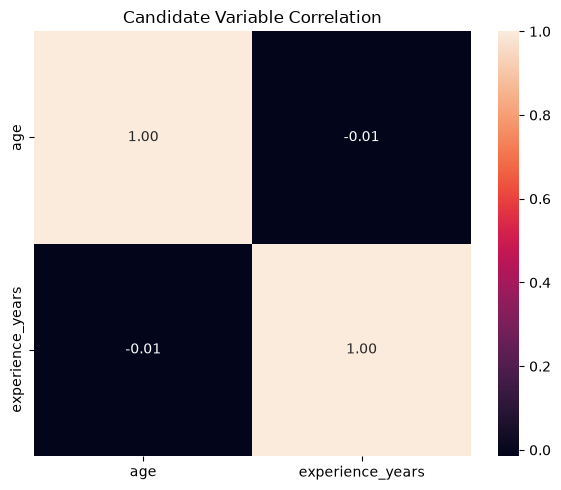

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Candidate Variable Correlation')

plt.tight_layout()
plt.show()

In [39]:
ml_data = (
    applications
    .merge(
        candidates[
            ['candidate_id', 'age', 'experience_years', 'highest_education']
        ],
        on='candidate_id'
    )
    .merge(
        jobs[
            ['job_id', 'job_title', 'department', 'employment_type']
        ],
        on='job_id'
    )
    .merge(
        sources[['source_id', 'source_name']],
        on='source_id'
    )
    .merge(
        hires[['application_id']],
        on='application_id',
        how='left',
        indicator=True
    )
)

ml_data['hired'] = (
    ml_data['_merge'] == 'both'
).astype(int)

ml_data = ml_data.drop(columns=['_merge'])

ml_data.head()

,application_id,candidate_id,job_id,source_id,recruiter_id,application_date,application_status,age,experience_years,highest_education,job_title,department,employment_type,source_name,hired
0,1,29,2,1,19,2025-04-16,Rejected,35,4.3,M.Tech,Frontend Developer,Engineering,Full-time,LinkedIn,0
1,2,102,19,11,1,2025-07-22,Screening,30,1.7,M.Com,ML Engineer,Data,Full-time,Consultancy,0
2,3,123,14,11,18,2025-10-30,Rejected,28,1.2,M.Com,Data Scientist,Data,Full-time,Consultancy,0
3,4,54,8,5,17,2025-06-09,Interview,32,6.7,B.Sc,Product Manager,Product,Contract,Referral,0
4,5,1307,19,1,1,2025-08-29,Applied,28,6.8,B.Tech,ML Engineer,Data,Full-time,LinkedIn,0


In [40]:
ml_data['hired'].value_counts()

hired
0    9514
1     486
Name: count, dtype: int64

In [41]:
features = [
    'age',
    'experience_years',
    'highest_education',
    'job_title',
    'department',
    'employment_type',
    'source_name'
]

X = ml_data[features]
y = ml_data['hired']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 7)
Target shape: (10000,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = [
    'age',
    'experience_years'
]

categorical_features = [
    'highest_education',
    'job_title',
    'department',
    'employment_type',
    'source_name'
]

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [44]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred = logistic_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.529
Precision: 0.05
Recall: 0.485
F1 Score: 0.091

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.53      0.68      1903
           1       0.05      0.48      0.09        97

    accuracy                           0.53      2000
   macro avg       0.50      0.51      0.39      2000
weighted avg       0.91      0.53      0.65      2000



In [46]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[1012,  891],
       [  50,   47]])

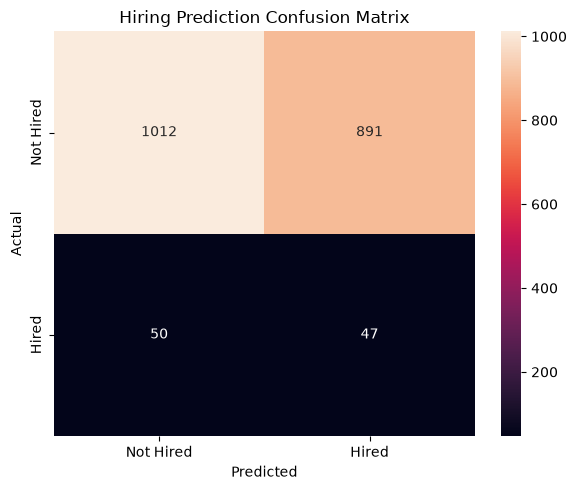

In [47]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Hired', 'Hired'],
    yticklabels=['Not Hired', 'Hired']
)

plt.title('Hiring Prediction Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [49]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        rf_accuracy
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        rf_precision
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        rf_recall
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        rf_f1
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.530,0.050,0.485,0.091
1,Random Forest,0.936,0.029,0.010,0.015


In [50]:
rf_model = random_forest_model.named_steps['model']
rf_preprocessor = random_forest_model.named_steps['preprocessor']

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

feature_importance.head(15)

,feature,importance
1,num__experience_years,0.270655
0,num__age,0.208189
37,cat__source_name_Naukri,0.026220
36,cat__source_name_LinkedIn,0.024418
8,cat__highest_education_MCA,0.021674
7,cat__highest_education_MBA,0.021213
6,cat__highest_education_M.Tech,0.021064
3,cat__highest_education_B.Sc,0.020853
39,cat__source_name_Referral,0.020488
5,cat__highest_education_M.Com,0.020337


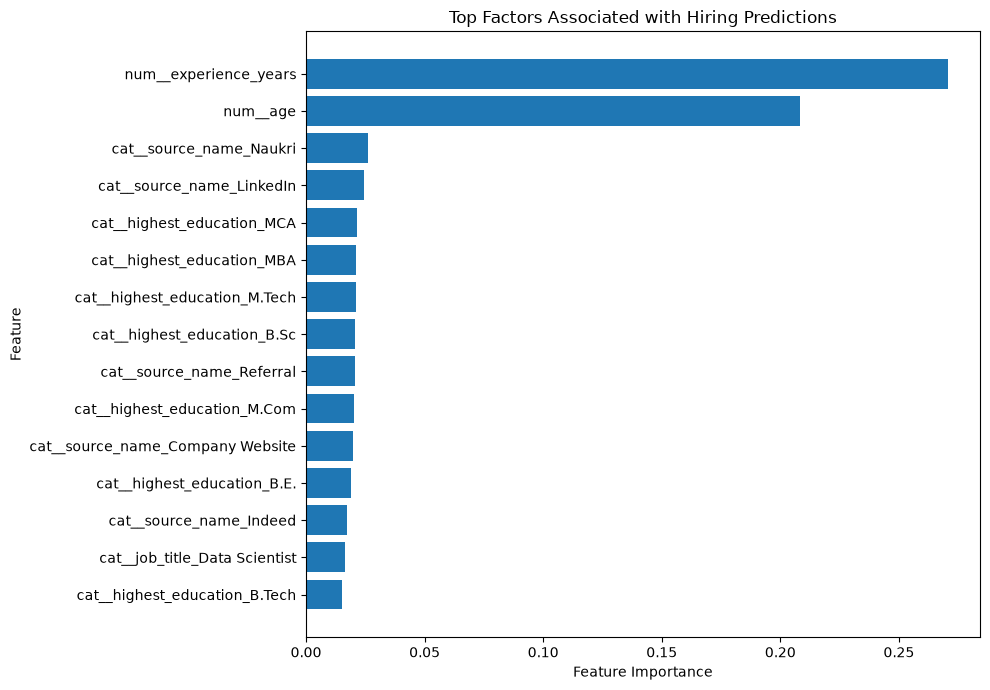

In [51]:
top_features = feature_importance.head(15).sort_values('importance')

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.title('Top Factors Associated with Hiring Predictions')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [52]:
output_dir = BASE_DIR / "ml"
output_dir.mkdir(exist_ok=True)

model_comparison.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    output_dir / "feature_importance.csv",
    index=False
)

source_summary.to_csv(
    output_dir / "source_performance.csv"
)

recruiter_summary.to_csv(
    output_dir / "recruiter_performance.csv"
)

role_salary.to_csv(
    output_dir / "role_salary_analysis.csv"
)

print("ML and analysis results saved successfully!")

ML and analysis results saved successfully!
